# 1. Introduction

Personal expense management is essential for understanding spending habits and making informed financial decisions. This project analyzes a publicly available personal expense dataset to identify spending patterns, evaluate category-wise expenses, and uncover trends over time using exploratory data analysis (EDA).

The analysis is performed using Python and its data analysis libraries, including Pandas, Matplotlib, and Seaborn. Through data cleaning, visualization, and statistical exploration, the project aims to transform raw expense records into meaningful insights and practical budgeting recommendations.

## Objectives

* Understand the structure and quality of the dataset.
* Clean and prepare the data for analysis.
* Explore spending patterns across categories and time.
* Visualize expense distributions and trends.
* Generate actionable insights to support better financial decision-making.


2. Import Libraries

In [21]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


3. Load and Understand Data

In [29]:
df = pd.read_csv("et.csv")
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


4. Dataset Overview

In [23]:
print("Shape:", df.shape)
df.info()
print("Columns:", df.columns)

Shape: (277, 11)
<class 'pandas.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    str    
 1   Account         277 non-null    str    
 2   Category        277 non-null    str    
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    str    
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    str    
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    str    
 10  Account.1       277 non-null    float64
dtypes: float64(5), str(6)
memory usage: 23.9 KB
Columns: Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1'],
      dtype='str')


In [24]:
df.describe()

,Subcategory,INR,Note.1,Amount,Account.1
count,0.0,277.000000,0.0,277.000000,277.000000
mean,NaN,410.750903,NaN,406.759134,406.759134
std,NaN,1065.756569,NaN,1065.158318,1065.158318
min,NaN,3.000000,NaN,3.000000,3.000000
25%,NaN,50.000000,NaN,50.000000,50.000000
50%,NaN,128.000000,NaN,125.000000,125.000000
75%,NaN,301.150000,NaN,300.000000,300.000000
max,NaN,10000.000000,NaN,10000.000000,10000.000000


In [25]:
#Missing values per column
df.isnull().sum()



Date                0
Account             0
Category            0
Subcategory       277
Note                4
INR                 0
Income/Expense      0
Note.1            277
Amount              0
Currency            0
Account.1           0
dtype: int64

In [4]:
#Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Duplicate rows: 0


,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1


In [5]:
df.dtypes

Date                  str
Account               str
Category              str
Subcategory       float64
Note                  str
INR               float64
Income/Expense        str
Note.1            float64
Amount            float64
Currency              str
Account.1         float64
dtype: object

5. Data Cleaning

Approach:
Missing Amount: filled using the median Amount for that transaction's Category, since spending scale varies a lot by category (a missing Rent value shouldn't be filled with the same number as a missing Coffee value).
Missing Category: filled with "Uncategorized" rather than dropped, so we don't lose real spending data — and the size of this bucket becomes its own insight.



In [11]:
# Fill missing SUbcategory first (Amount fill below depends on Subcategory groups)
df['Subcategory'] = df['Subcategory'].fillna('Uncategorized')

# Fill missing Note using the fillna
df['Note'] = df['Note'].fillna('No Note')

# Fill missing Note.1 using the fillna
df['Note.1'] = df['Note.1'].fillna('No Note')

# Confirm no missing values remain
df.isnull().sum()

Date              0
Account           0
Category          0
Subcategory       0
Note              0
INR               0
Income/Expense    0
Note.1            0
Amount            0
Currency          0
Account.1         0
dtype: int64

In [14]:
#Correcting data types
df['Date'] = pd.to_datetime(df['Date'])
df['Account'] = df['Account'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Subcategory'] = df['Subcategory'].astype('category')
df['Income/Expense'] = df['Income/Expense'].astype('category')
df['Note.1'] = df['Note.1'].astype('str')
df['Currency'] = df['Currency'].astype('category')
df.dtypes

Date              datetime64[us]
Account                 category
Category                category
Subcategory             category
Note                         str
INR                      float64
Income/Expense          category
Note.1                       str
Amount                   float64
Currency                category
Account.1                float64
dtype: object

In [30]:
#Save the cleaned dataset
df.to_csv("cleaned_expense.csv", index=False)
print("Saved cleaned_expense.csv with shape:", df.shape)

Saved cleaned_expense.csv with shape: (277, 11)


6. Exploratory Data Analysis

In [31]:
# Total expenses
total_expense = df['Amount'].sum()
print(f"Total Expenses: {total_expense:,.2f}")

# avg,min,max
print(f"Average Expense: {df['Amount'].mean():,.2f}")
print(f"Maximum Expense: {df['Amount'].max():,.2f}")
print(f"Minimum Expense: {df['Amount'].min():,.2f}")


Total Expenses: 112,672.28
Average Expense: 406.76
Maximum Expense: 10,000.00
Minimum Expense: 3.00


In [32]:
# Highest spending category
category_totals = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print("\nTotal Spending by category (highest first):")
print(category_totals)
print(f"\nHighest spending category: {category_totals.idxmax()} ({category_totals.max():,.2f})")


Total Spending by category (highest first):
Category
Other               37868.00
Food                23396.76
Allowance           14000.00
Household           12188.00
Transportation       9203.80
Salary               8000.00
Apparel              3388.00
Social Life          2513.72
Education            1400.00
Self-development      400.00
Beauty                196.00
Gift                  115.00
Petty cash              3.00
Name: Amount, dtype: float64

Highest spending category: Other (37,868.00)


In [34]:
# Count of transactions by category
category_counts = df['Category'].value_counts()
print("\nTransaction count by category:")
print(category_counts)


Transaction count by category:
Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64


Even though the other category has highest spending, but the food category is the category with most transaction

7. Visualizations 

7.1 Histogram of Expense Amounts

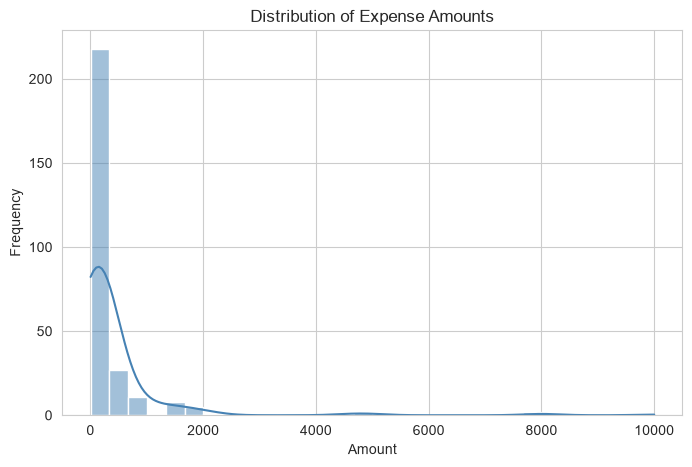

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Expense Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

Observations:
- Distribution is right‑skewed (many small expenses, few large ones).
- Peak/mode occurs near 0 (small amounts dominate).
- Long tail extends toward higher amounts (large expenses are rare).

 7.2 Boxplot of Expense Amounts

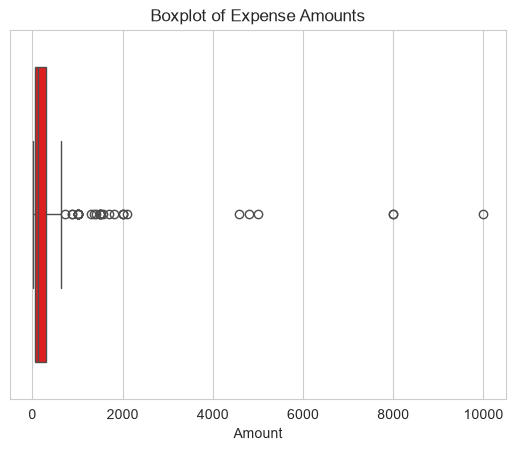

In [ ]:

sns.boxplot(x=df['Amount'], color='red')
plt.title('Boxplot of Expense Amounts')
plt.show()

Box shows middle 50% of expenses (IQR) → clustered at low amounts.
Outliers (≈4–5) at 2k, 4k, 8k, 10k → rare but significant large expenses.
Typical spending is small and stable; few extreme values stretch the scale.

In [14]:
#Analyzig the spending patterns over time by creating new following columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()
df["Weekday"] = df["Date"].dt.dayofweek
df.head()


,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Year,Month,Day,Weekday
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,2022,March,Wednesday,2
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,2022,March,Wednesday,2
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,2022,March,Tuesday,1
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,2022,March,Tuesday,1
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,2022,March,Tuesday,1


### 7.3 Bar Chart — Total Spending by Category

In [21]:
#Total spending by months
df.groupby("Month")["Amount"].sum()



Month
December    27538.72
February    36064.65
January     40320.51
March        1125.00
November     7623.40
Name: Amount, dtype: float64

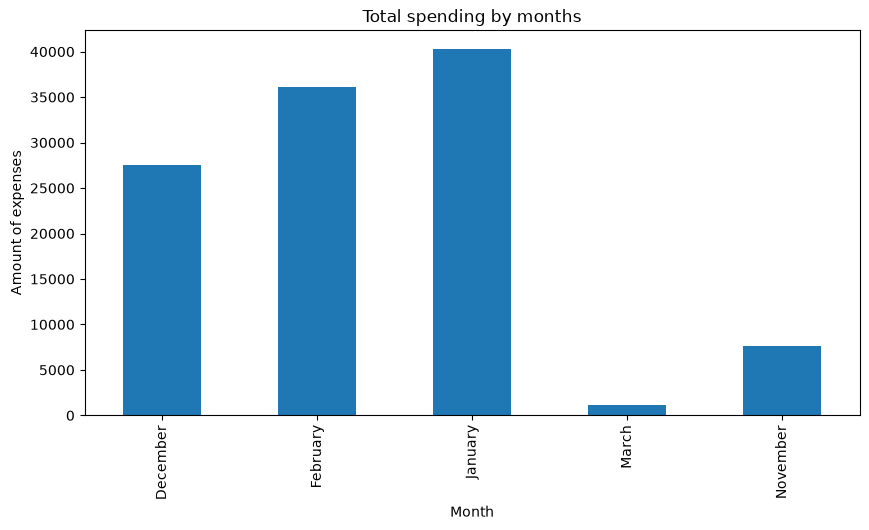

In [ ]:
#Visualizing Total spending by months
df.groupby("Month")["Amount"].sum().plot(kind='bar', figsize=(10,5))
plt.title("Total spending by months")
plt.xlabel("Month")
plt.ylabel("Amount of expenses")
plt.show()



From the bargraph we can observe that month March have the least spending, and month January have the most spending

In [ ]:
#Number of transactions per month
df.groupby("Month").size()

Month
December    89
February    54
January     92
March        7
November    35
dtype: int64

We can observe that, the number of transaction is directly propotional to the spending per month

In [26]:
#spending by day of the week
df.groupby("Day")["Amount"].sum().sort_values(ascending=True)


Day
Monday        6248.95
Wednesday     6634.75
Friday        6910.00
Thursday      9570.51
Tuesday      17344.65
Sunday       31542.40
Saturday     34421.02
Name: Amount, dtype: float64

Peak spending on weekends, higher spedings on thurs & tues, mid-range spending on wed & fri and lowest spending on the start day of week

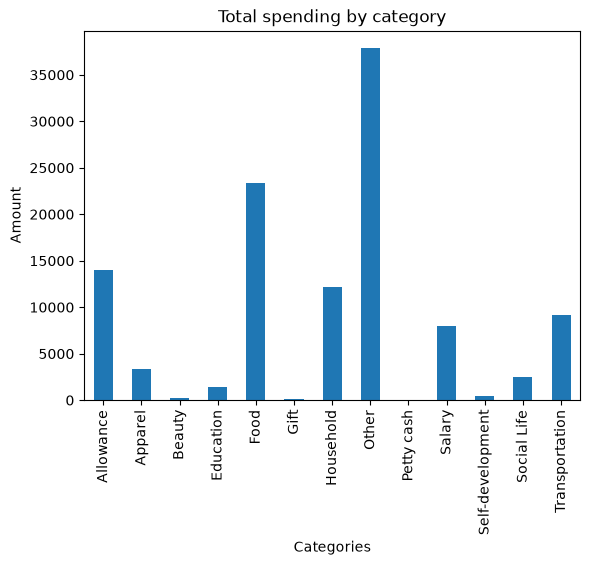

In [ ]:
# Total spending by category
df.groupby("Category")["Amount"].sum().plot(kind ='bar')
plt.title("Total spending by category")
plt.xlabel("Categories")
plt.ylabel("Amount")
plt.show()

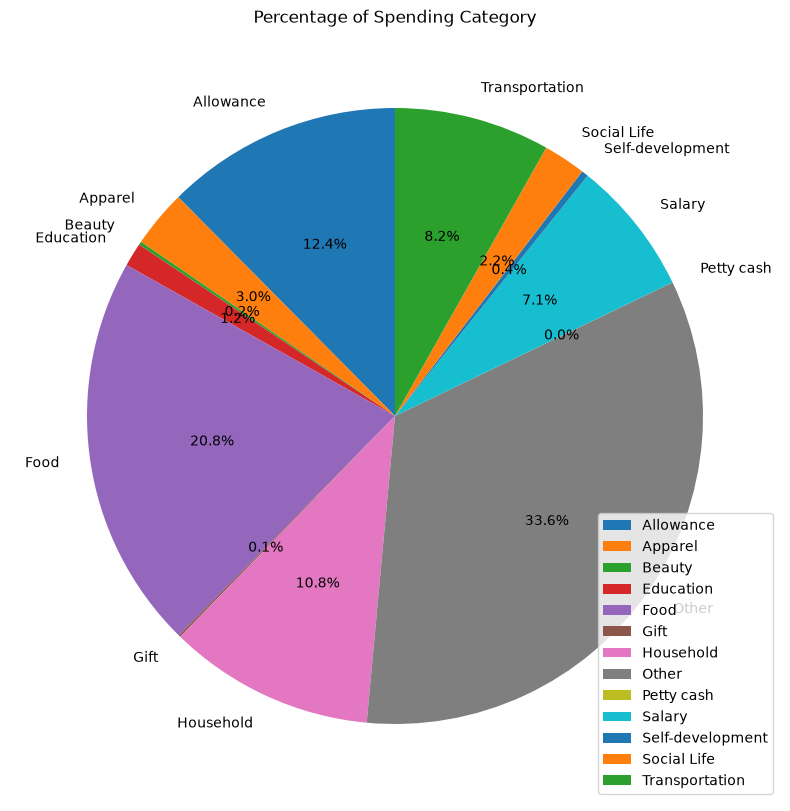

In [ ]:
#Percentage of spending categroy
df.groupby("Category")["Amount"].sum().plot(kind = 'pie',  
                                            autopct='%1.1f%%',
                                            startangle = 90,
                                            legend = True,       #legend : The pie chart shows only percentages (or values) on the slices.
                                            figsize = (10,10))
plt.title("Percentage of Spending Category")
plt.ylabel("")  #remove default y-label
plt.show()

# 5. Key Insights & Findings

## Spending Patterns
- **Total expenses** are dominated by a few large transactions, with most individual expenses being small amounts
- **January** records the highest spending, while **March** has the lowest, with spending directly correlated to transaction frequency
- **Weekends and mid-week** (Thursday, Tuesday) show peak spending, while **Mondays** have the lowest transaction activity

## Category Analysis
- **"Other" category** is the largest expense driver and requires close monitoring to identify and reduce unclassified spending
- **Food and Allowance** categories consist of fewer but larger transactions that significantly impact the budget
- **Small transaction categories** (petty cash, self-development, beauty, gifts) are frequent but individually minor—they accumulate unnoticed

## Recommendations for Budget Management
1. **Prioritize "Other" category** - Implement alerts and review unclassified transactions regularly to prevent budget leakage
2. **Consolidate small transactions** - Set spending caps for small frequent categories to prevent accumulation
3. **Track large transactions** - Focus budgeting controls on Food and Allowance categories as they drive overall spending
4. **Optimize timing** - Review mid-week and weekend spending patterns to identify discretionary opportunities
5. **Future planning** - Consider redirecting surplus funds toward savings, investments, and insurance after controlling discretionary spending

# 9. Conclusion

This project analyzed a personal expense dataset to understand spending behavior using Python, Pandas, Matplotlib, and Seaborn. The analysis included data cleaning, exploratory data analysis, and visualization of spending trends across categories and time.

The findings reveal that while most transactions are relatively small, a few high-value expenses account for a significant portion of total spending. The **Other** category contributes the highest overall expenditure, whereas **Food** records the highest number of transactions. Monthly and weekly spending patterns also highlight periods of increased expenditure, providing opportunities for better financial planning.

Overall, this analysis demonstrates how exploratory data analysis can transform raw financial data into meaningful insights that support informed budgeting decisions and identify areas where spending can be optimized.
